In [ ]:
# Write the Sharpe Ratio formula. What's a good Sharpe? What's suspicious?
sharpe = (bot_returns - risk_free_rate)/ std

In [1]:
# Write the three annualisation formulas.
import numpy as np

daily_mean = 0.0005
std = 0.025
risk_free_rate = 0.05
no_trades = 365

annualised_log_return = daily_mean * no_trades
annualised_simple_return = np.exp(annualised_log_return) - 1
annualised_vol = std * np.sqrt(no_trades)

sharpe = (annualised_log_return - risk_free_rate)/ annualised_vol

# Name three reasons to be skeptical of a backtest.
1. How the test was conducted, is vs oos, timeframe, transaction cost, parameters, sharpe ratio, expected value

LINEAR EQUATIONS — 
WHY y = mx + b IS MACHINE LEARNING

Your bot needs to predict BTC's next move. Every prediction model — from the simplest to the most complex — is fundamentally doing one thing: finding a relationship between inputs and outputs. "When THIS happens, THAT tends to follow."

The simplest possible relationship is a straight line. And the equation for a straight line is the foundation of ALL machine learning.

1. y — the thing you're trying to predict. Tomorrow's BTC return.
2. x — the thing you're using to predict. Today's trading volume.
3. m — the slope. How much y changes when x changes by 1 unit. This is the RELATIONSHIP your model learns.
4. b — the intercept. What y equals when x is zero. The baseline.




In [5]:
days = list(range(11))
prices = [60000 + 500 * d for d in days]

m = 500
b = 60000

print(f"Day 0: ${b + m * 0:,}")
print(f"Day 0: ${b + m * 10:,}")

# slope between any two points
# m = (y2 - y1) / (x2 - x1)

Day 0: $60,000
Day 0: $65,000


In [6]:
# BTC was $60,000 on day 1, $63,000 on day 7
# What's the slope (rate of change per day)?

y1, y2 = 60000, 63000
x1, x2 = 1, 7

m = (y2 - y1) / (x2 - x1)
print(f"Slope: ${m:,.0f} per day")  # $500 per day

# Now find the intercept
# y = mx + b → b = y - mx
b = y1 - m * x1
print(f"Intercept: ${b:,.0f}")

# Predict day 14
day_14 = m * 14 + b
print(f"Day 14 prediction: ${day_14:,.0f}")

Slope: $500 per day
Intercept: $59,500
Day 14 prediction: $66,500


/var/folders/x7/_9kdc2hd3g3d62j28dsz3nx40000gn/T/ipykernel_5773/4292009029.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2023-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed
/var/folders/x7/_9kdc2hd3g3d62j28dsz3nx40000gn/T/ipykernel_5773/4292009029.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eth = yf.download("ETH-USD", start="2023-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


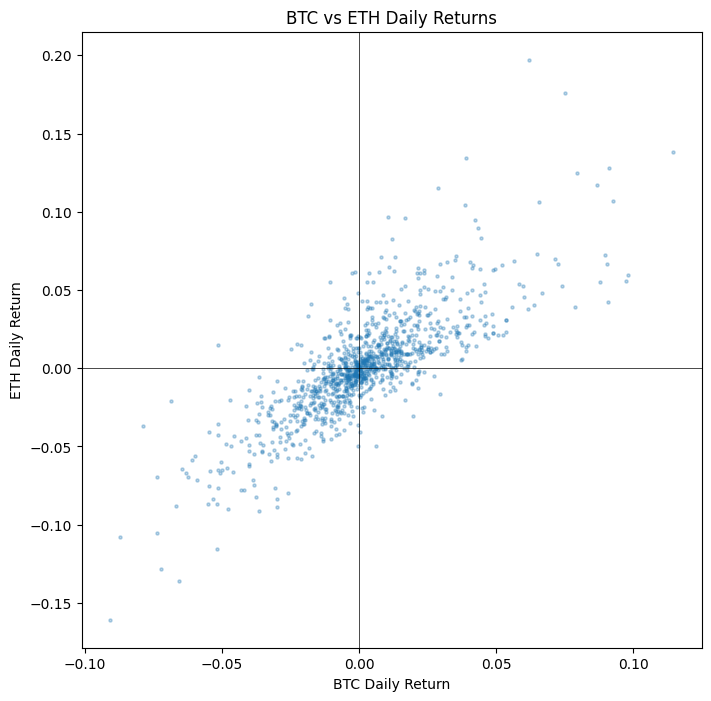

In [7]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

btc = yf.download("BTC-USD", start="2023-01-01", end="2025-12-31")
eth = yf.download("ETH-USD", start="2023-01-01", end="2025-12-31")

btc.columns = btc.columns.droplevel(1)
eth.columns = eth.columns.droplevel(1)

btc_returns = np.log(btc["Close"] / btc["Close"].shift(1)).dropna()
eth_returns = np.log(eth["Close"] / eth["Close"].shift(1)).dropna()

# Plot BTC returns vs ETH returns
plt.figure(figsize=(8, 8))
plt.scatter(btc_returns, eth_returns, alpha=0.3, s=5)
plt.xlabel("BTC Daily Return")
plt.ylabel("ETH Daily Return")
plt.title("BTC vs ETH Daily Returns")
plt.axhline(y=0, color="black", linewidth=0.5)
plt.axvline(x=0, color="black", linewidth=0.5)
plt.show()

In [8]:
# Pick two points from the data
# Average BTC return on days BTC was up vs down
btc_up_days = btc_returns > 0
btc_down_days = btc_returns < 0

avg_btc_up = btc_returns[btc_up_days].mean()
avg_eth_on_btc_up = eth_returns[btc_up_days].mean()

avg_btc_down = btc_returns[btc_down_days].mean()
avg_eth_on_btc_down = eth_returns[btc_down_days].mean()

slope = (avg_eth_on_btc_up - avg_eth_on_btc_down) / (avg_btc_up - avg_btc_down)
print(f"Approximate slope (ETH vs BTC): {slope:.2f}")

Approximate slope (ETH vs BTC): 1.10


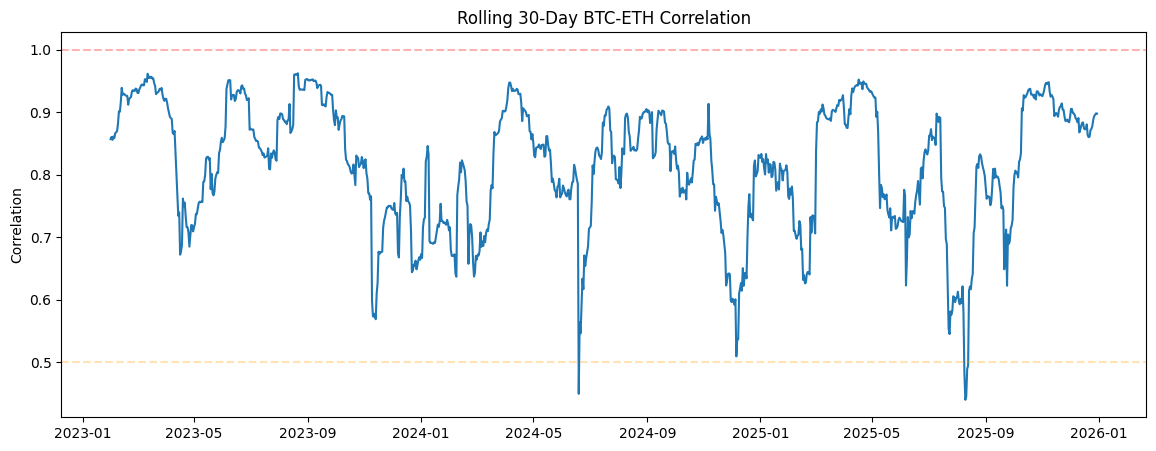

In [9]:
# Rolling 30-day slope approximation
# Correlation as a proxy for relationship stability
rolling_corr = btc_returns.rolling(30).corr(eth_returns)

plt.figure(figsize=(14, 5))
plt.plot(rolling_corr)
plt.axhline(y=1.0, color="red", linestyle="--", alpha=0.3)
plt.axhline(y=0.5, color="orange", linestyle="--", alpha=0.3)
plt.title("Rolling 30-Day BTC-ETH Correlation")
plt.ylabel("Correlation")
plt.show()

In [ ]:
def slope_intercept(x1, y1, x2, y2):
    m = (y2 - y1) / (x2 - x1)
    b = y1 - m * x1
    return m, b

# beta how mcuh an asset moves relative to the market. For example if BTC moves up 1% then ETH moves up 1.5% that's the slope and thats beta

# If it drops from 0.85 to 0.3 then its startign to decouple or some sort of news driven, could be used as a signal or regime change